# Small-footprint keyword spotting
## 2. STFT and MFCC comparison with a baseline CNN

This notebook evaluates two audio representations, STFT and MFCC, for speech command classification using a convolutional neural network (CNN).

Both models share the same architecture and training configuration. The objective is to compare how the choice of input features affects classification performance while keeping the remaining experimental conditions consistent.

In [ ]:
import sklearn
from pathlib import Path
import sys
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from preprocessing import load_audio, extract_stft, extract_mfcc


2026-10-08 10:18:01.068079: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1791447481.174880    6585 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1791447481.201058    6585 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1791447481.391860    6585 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1791447481.391902    6585 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1791447481.391905    6585 computation_placer.cc:177] computation placer alr

In [2]:
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "speech_commands_v0.02"
MANIFEST_PATH = PROJECT_ROOT / "data" / "processed" / "speech_commands_manifest.csv"
LABELS_PATH = PROJECT_ROOT / "data" / "processed" / "labels.json"
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed"

if not MANIFEST_PATH.is_file() or not LABELS_PATH.is_file():
    raise FileNotFoundError("Run notebook 1 first to create the split manifest and label list.")
manifest = pd.read_csv(MANIFEST_PATH)
labels = json.loads(LABELS_PATH.read_text())
num_classes = len(labels)
print(f"{len(manifest):,} recordings | {num_classes} classes")
print(manifest.groupby("split").size())
print("GPU devices:", tf.config.list_physical_devices("GPU"))


105,829 recordings | 35 classes
split
test          11005
train         84843
validation     9981
dtype: int64
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Build datasets from the fixed manifest

The training, validation, and test partitions are loaded from the manifest generated during data preprocessing. I use the same partitions for both experiments to make the comparison consistent.
Audio features are extracted during data loading, avoiding the need to store a separate feature dataset.

In [3]:
BATCH_SIZE = 64
SEED = 42
EPOCHS = 40
EARLY_STOPPING_PATIENCE = 10


def make_dataset(split_name, feature_name):
    rows = manifest.loc[manifest["split"] == split_name]
    paths = rows["path"].astype(str).to_numpy()
    targets = rows["label_id"].to_numpy(dtype=np.int32)
    if len(paths) == 0:
        raise ValueError(f"The {split_name} split is empty.")

    if feature_name == "STFT":
        extractor = extract_stft
        feature_shape = (124, 129, 1)
    elif feature_name == "MFCC":
        extractor = extract_mfcc
        feature_shape = (99, 13, 1)
    else:
        raise ValueError("feature_name must be 'STFT' or 'MFCC'.")

    def load_features(relative_path, target):
        relative_path = relative_path.decode("utf-8")
        waveform = load_audio(DATA_DIR / relative_path)
        features = extractor(waveform)
        return features.astype(np.float32), np.int32(target)

    def map_record(relative_path, target):
        features, label_id = tf.numpy_function(
            load_features, [relative_path, target], [tf.float32, tf.int32]
        )
        features.set_shape(feature_shape)
        label_id.set_shape(())
        return features, label_id

    dataset = tf.data.Dataset.from_tensor_slices((paths, targets))
    if split_name == "train":
        dataset = dataset.shuffle(min(len(paths), 20_000), seed=SEED, reshuffle_each_iteration=True)
    return dataset.map(map_record, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


## 2. Define the same baseline CNN for both inputs

Both models use the same CNN architecture. STFT and MFCC feature maps are resized to 32 × 32 before entering the convolutional layers.
Early stopping is used to reduce overfitting, with the best weights restored according to validation loss.

In [4]:
def build_cnn(input_shape, class_count, training_dataset):
    normalization = tf.keras.layers.Normalization()
    normalization.adapt(training_dataset.map(lambda features, _label: features))

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Resizing(32, 32),
        normalization,
        tf.keras.layers.Conv2D(32, 3, activation="relu"),
        tf.keras.layers.Conv2D(64, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Dropout(0.25),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(class_count, activation="softmax"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
    )
    return model


## 3. Train and evaluate each representation

I trained two CNN models, one using STFT features and the other using MFCC features. Both experiments use the same batch size, maximum number of epochs, and early-stopping configuration.
After training, each model is evaluated on the test set, and the results are saved for comparison with the recurrent models.

In [5]:
def run_experiment(feature_name):
    tf.keras.utils.set_random_seed(SEED)
    train_data = make_dataset("train", feature_name)
    validation_data = make_dataset("validation", feature_name)
    test_data = make_dataset("test", feature_name)
    input_shape = (124, 129, 1) if feature_name == "STFT" else (99, 13, 1)
    model = build_cnn(input_shape, num_classes, train_data)

    started = time.perf_counter()
    history = model.fit(
        train_data,
        validation_data=validation_data,
        epochs=EPOCHS,
        callbacks=[tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=EARLY_STOPPING_PATIENCE,
            restore_best_weights=True,
        )],
        verbose=1,
    )
    training_seconds = time.perf_counter() - started
    test_loss, test_accuracy = model.evaluate(test_data, verbose=0)

    result = {
        "feature": feature_name,
        "epochs_trained": len(history.history["loss"]),
        "best_val_accuracy": max(history.history["val_accuracy"]),
        "test_accuracy": float(test_accuracy),
        "test_loss": float(test_loss),
        "training_seconds": training_seconds,
    }
    print(result)
    return result, history, model, test_data


In [6]:
results = []
histories = {}
models_by_feature = {}

for feature_name in ["STFT", "MFCC"]:
    result, history, model, test_data = run_experiment(feature_name)
    results.append(result)
    histories[feature_name] = history.history
    models_by_feature[feature_name] = model

results_df = pd.DataFrame(results)
display(results_df)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
results_df.to_csv(OUTPUT_DIR / "cnn_feature_comparison.csv", index=False)


I0000 00:00:1791447497.963287    6585 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2140 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6
2026-10-08 10:19:00.894630: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 1/40


/home/stefano98/miniconda3/envs/speech-command-recognition/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1791447542.608225    6885 service.cc:152] XLA service 0x7eab3c00ba80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1791447542.608248    6885 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2026-10-08 10:19:02.699472: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1791447542.915099    6885 cuda_dnn.cc:529] Loaded cuDNN version 90300
2026-10-08 10:19:03.916505: I external/local_xl

   7/1326 ━━━━━━━━━━━━━━━━━━━━ 25s 19ms/step - accuracy: 0.1429 - loss: 3.1298

I0000 00:00:1791447547.512030    6885 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


...

2026-10-08 10:19:51.013960: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_212', 164 bytes spill stores, 164 bytes spill loads

2026-10-08 10:19:57.104431: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_212', 172 bytes spill stores, 172 bytes spill loads



1326/1326 ━━━━━━━━━━━━━━━━━━━━ 57s 38ms/step - accuracy: 0.4257 - loss: 2.1087 - val_accuracy: 0.5181 - val_loss: 1.6982
Epoch 2/40
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 42s 32ms/step - accuracy: 0.6325 - loss: 1.2449 - val_accuracy: 0.6347 - val_loss: 1.2151
Epoch 3/40
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 44s 33ms/step - accuracy: 0.6971 - loss: 1.0132 - val_accuracy: 0.6712 - val_loss: 1.1116
Epoch 4/40
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 44s 33ms/step - accuracy: 0.7310 - loss: 0.8925 - val_accuracy: 0.7072 - val_loss: 0.9727
Epoch 5/40
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 43s 32ms/step - accuracy: 0.7554 - loss: 0.8095 - val_accuracy: 0.7439 - val_loss: 0.8507
Epoch 6/40
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 43s 32ms/step - accuracy: 0.7730 - loss: 0.7472 - val_accuracy: 0.7728 - val_loss: 0.7518
Epoch 7/40
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 44s 33ms/step - accuracy: 0.7869 - loss: 0.6975 - val_accuracy: 0.7797 - val_loss: 0.7382
Epoch 8/40
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 44s 33ms/step - accuracy: 0.7969 - loss: 0.66

2026-10-08 10:50:31.992933: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/home/stefano98/miniconda3/envs/speech-command-recognition/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1326/1326 ━━━━━━━━━━━━━━━━━━━━ 116s 85ms/step - accuracy: 0.4496 - loss: 2.0133 - val_accuracy: 0.5546 - val_loss: 1.5463
Epoch 2/40
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 106s 80ms/step - accuracy: 0.6352 - loss: 1.2417 - val_accuracy: 0.6512 - val_loss: 1.1685
Epoch 3/40
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 112s 85ms/step - accuracy: 0.6979 - loss: 1.0054 - val_accuracy: 0.6894 - val_loss: 1.0808
Epoch 4/40
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 111s 84ms/step - accuracy: 0.7354 - loss: 0.8790 - val_accuracy: 0.7270 - val_loss: 0.9327
Epoch 5/40
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 112s 84ms/step - accuracy: 0.7589 - loss: 0.7896 - val_accuracy: 0.7583 - val_loss: 0.8291
Epoch 6/40
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 112s 84ms/step - accuracy: 0.7761 - loss: 0.7262 - val_accuracy: 0.7679 - val_loss: 0.7930
Epoch 7/40
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 112s 85ms/step - accuracy: 0.7914 - loss: 0.6782 - val_accuracy: 0.7729 - val_loss: 0.7805
Epoch 8/40
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 111s 84ms/step - accuracy: 0.7997 - lo

,feature,epochs_trained,best_val_accuracy,test_accuracy,test_loss,training_seconds
0,STFT,40,0.844004,0.822353,0.631353,1788.697389
1,MFCC,33,0.838293,0.814539,0.662977,3702.737509


## 4. Compare validation curves and test results

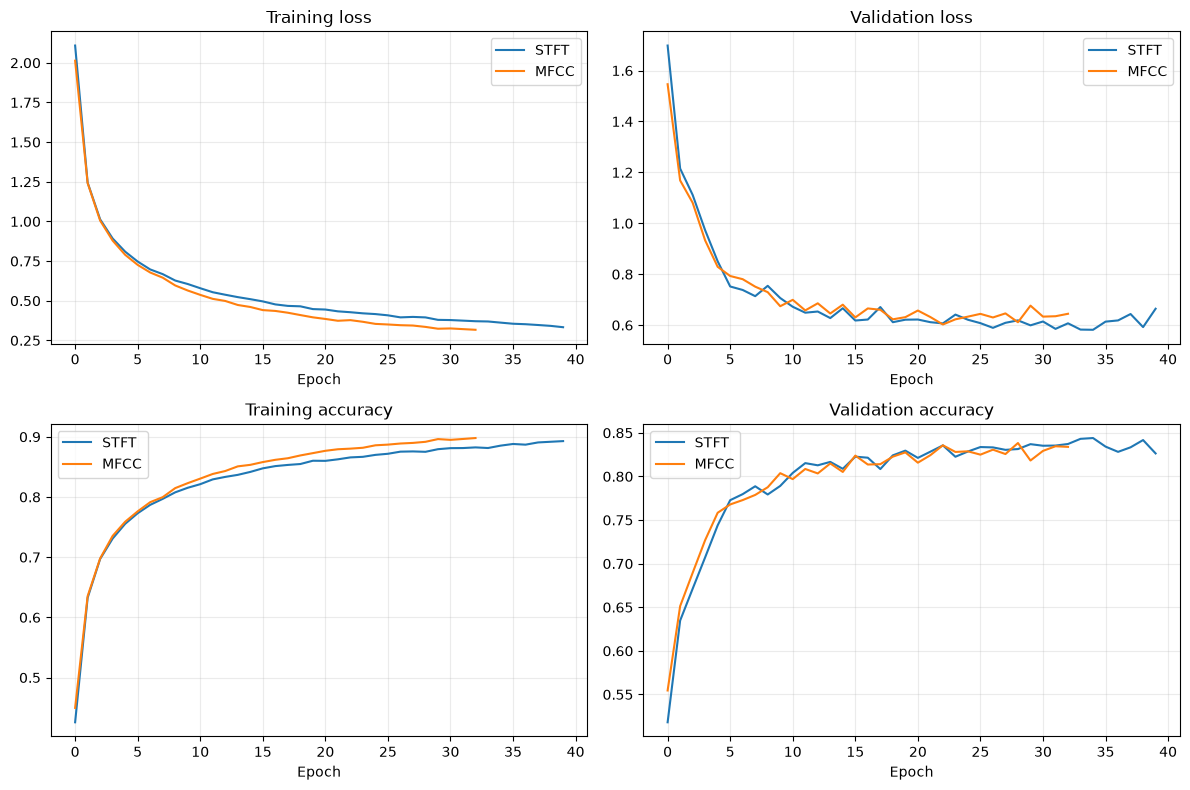

,test_accuracy,test_loss,training_seconds
feature,,,
STFT,0.822353,0.631353,1788.697389
MFCC,0.814539,0.662977,3702.737509


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for feature_name, history in histories.items():
    axes[0, 0].plot(history["loss"], label=feature_name)
    axes[0, 1].plot(history["val_loss"], label=feature_name)
    axes[1, 0].plot(history["accuracy"], label=feature_name)
    axes[1, 1].plot(history["val_accuracy"], label=feature_name)

for ax, title in zip(axes.flat, ["Training loss", "Validation loss", "Training accuracy", "Validation accuracy"]):
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.grid(alpha=0.25)
    ax.legend()
plt.tight_layout()
plt.show()

results_df.set_index("feature")[["test_accuracy", "test_loss", "training_seconds"]]


## 5. Summary

The CNN experiments provide a baseline for speech command classification
using two different audio representations.

The STFT model achieved slightly higher test accuracy than the MFCC model.
However, both representations produced comparable results.

In the next notebook, I evaluate LSTM and BiLSTM architectures to investigate
whether modeling temporal dependencies improves classification performance.

In [9]:
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

for feature_name, model in models_by_feature.items():

    model_path = MODEL_DIR / f"cnn_{feature_name.lower()}.keras"

    model.save(model_path)

    print(f"Saved {feature_name} model: {model_path}")

# Save training histories
with open(MODEL_DIR / "training_histories.json", "w") as f:
    json.dump(histories, f, indent=2)

# Save class labels alongside the models
with open(MODEL_DIR / "labels.json", "w") as f:
    json.dump(labels, f, indent=2)

print("\nAll models and metadata saved successfully!")

Saved STFT model: /home/stefano98/projects/speech-command-recognition/models/cnn_stft.keras
Saved MFCC model: /home/stefano98/projects/speech-command-recognition/models/cnn_mfcc.keras

All models and metadata saved successfully!


In [13]:
# ============================================================
# Detailed classification evaluation
# ============================================================

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

EVAL_DIR = PROJECT_ROOT / "results" / "cnn"
EVAL_DIR.mkdir(parents=True, exist_ok=True)

evaluation_results = {}

for feature_name, model in models_by_feature.items():

    print(f"\n{'=' * 50}")
    print(f"Evaluating {feature_name}")
    print(f"{'=' * 50}")

    # Load test dataset
    test_data = make_dataset("test", feature_name)

    y_true = []
    y_pred = []

    for x_batch, y_batch in test_data:

        probabilities = model.predict(x_batch, verbose=0)

        predictions = np.argmax(probabilities, axis=1)

        y_true.extend(y_batch.numpy())
        y_pred.extend(predictions)

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # Classification report
    report = classification_report(
        y_true,
        y_pred,
        labels=np.arange(num_classes),
        target_names=labels,
        output_dict=True,
        zero_division=0,
    )

    report_df = pd.DataFrame(report).transpose()

    report_df.to_csv(
        EVAL_DIR / f"{feature_name.lower()}_classification_report.csv"
    )

    # Global metrics
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "recall_macro": recall_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "f1_macro": f1_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "f1_weighted": f1_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
    }

    evaluation_results[feature_name] = metrics

    print("\nClassification report:")
    print(
        classification_report(
            y_true,
            y_pred,
            labels=np.arange(num_classes),
            target_names=labels,
            zero_division=0,
        )
    )

    # Save predictions for further analysis
    np.savez_compressed(
        EVAL_DIR / f"{feature_name.lower()}_predictions.npz",
        y_true=y_true,
        y_pred=y_pred,
    )

evaluation_df = pd.DataFrame(evaluation_results).T

display(evaluation_df)

evaluation_df.to_csv(EVAL_DIR / "evaluation_summary.csv")


Evaluating STFT

Classification report:
              precision    recall  f1-score   support

    backward       0.93      0.74      0.82       165
         bed       0.83      0.73      0.78       207
        bird       0.89      0.73      0.80       185
         cat       0.93      0.74      0.83       194
         dog       0.92      0.67      0.77       220
        down       0.89      0.75      0.81       406
       eight       0.94      0.75      0.84       408
        five       0.89      0.78      0.83       445
      follow       0.82      0.60      0.70       172
     forward       0.78      0.60      0.68       155
        four       0.82      0.78      0.80       400
          go       0.83      0.58      0.68       402
       happy       0.92      0.86      0.89       203
       house       0.92      0.85      0.89       191
       learn       0.78      0.50      0.61       161
        left       0.91      0.81      0.86       412
      marvin       0.91      0.78      0

2026-10-08 12:05:47.356087: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
STFT,0.822353,0.835966,0.803175,0.812364,0.820673
MFCC,0.814539,0.827834,0.790739,0.801099,0.813216


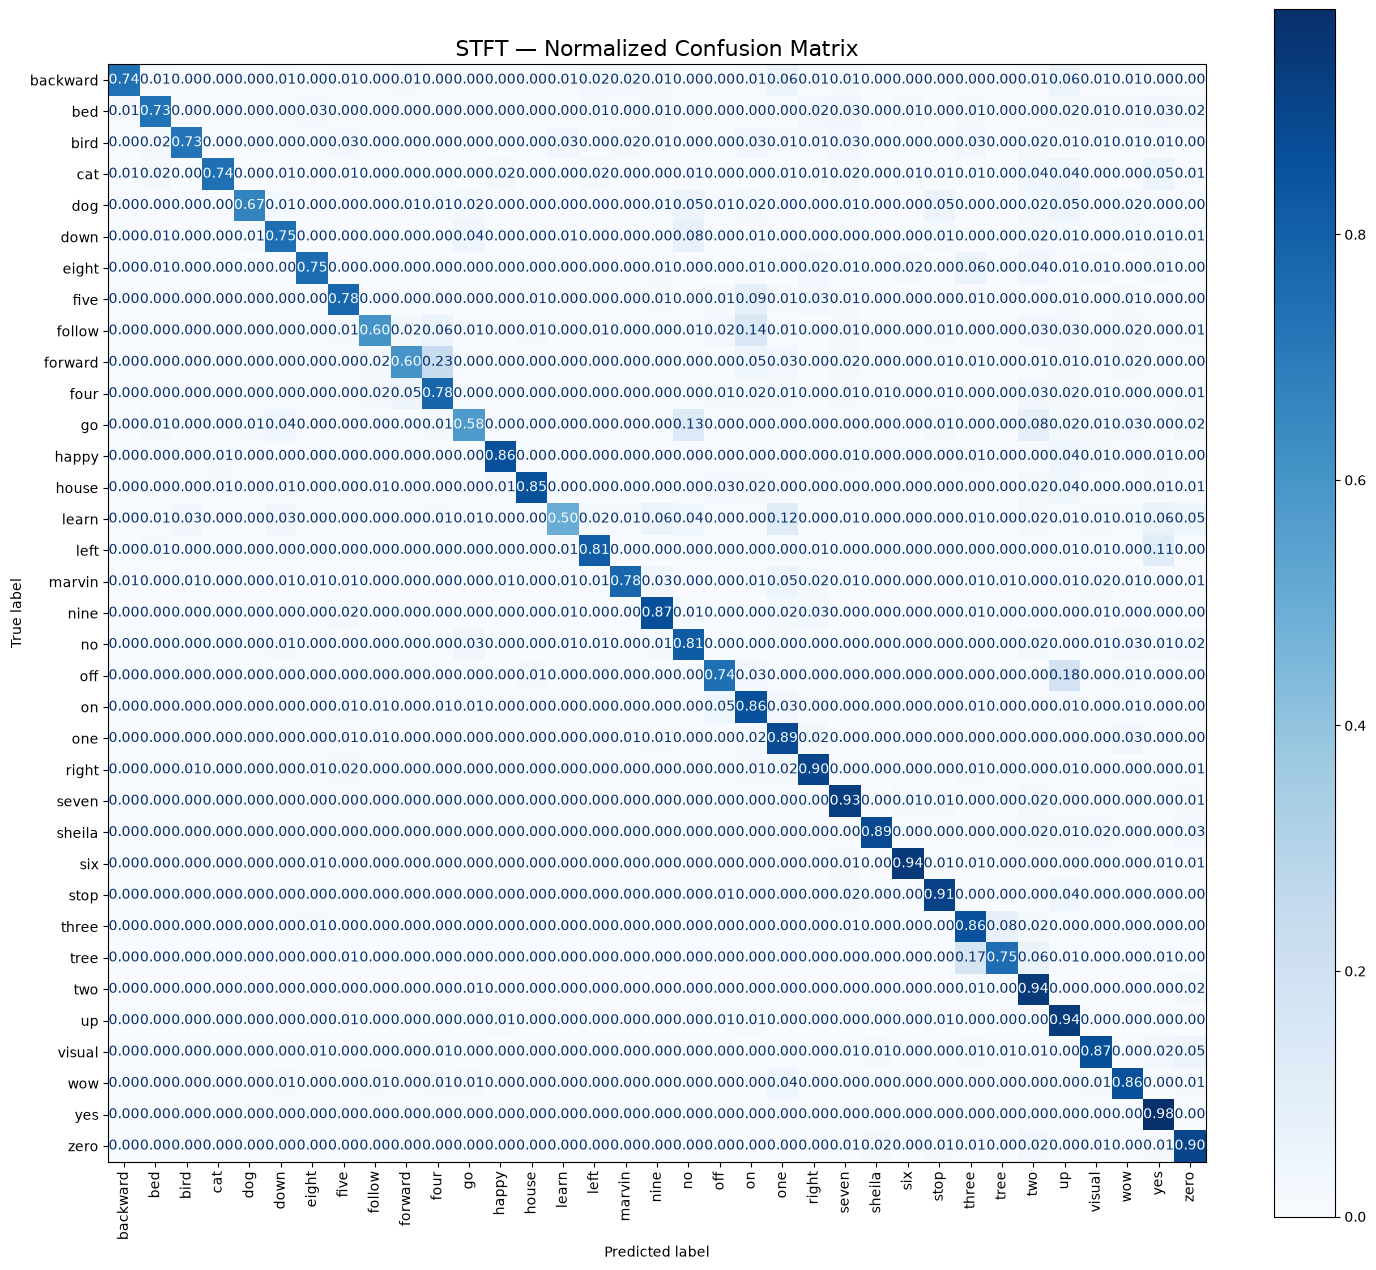

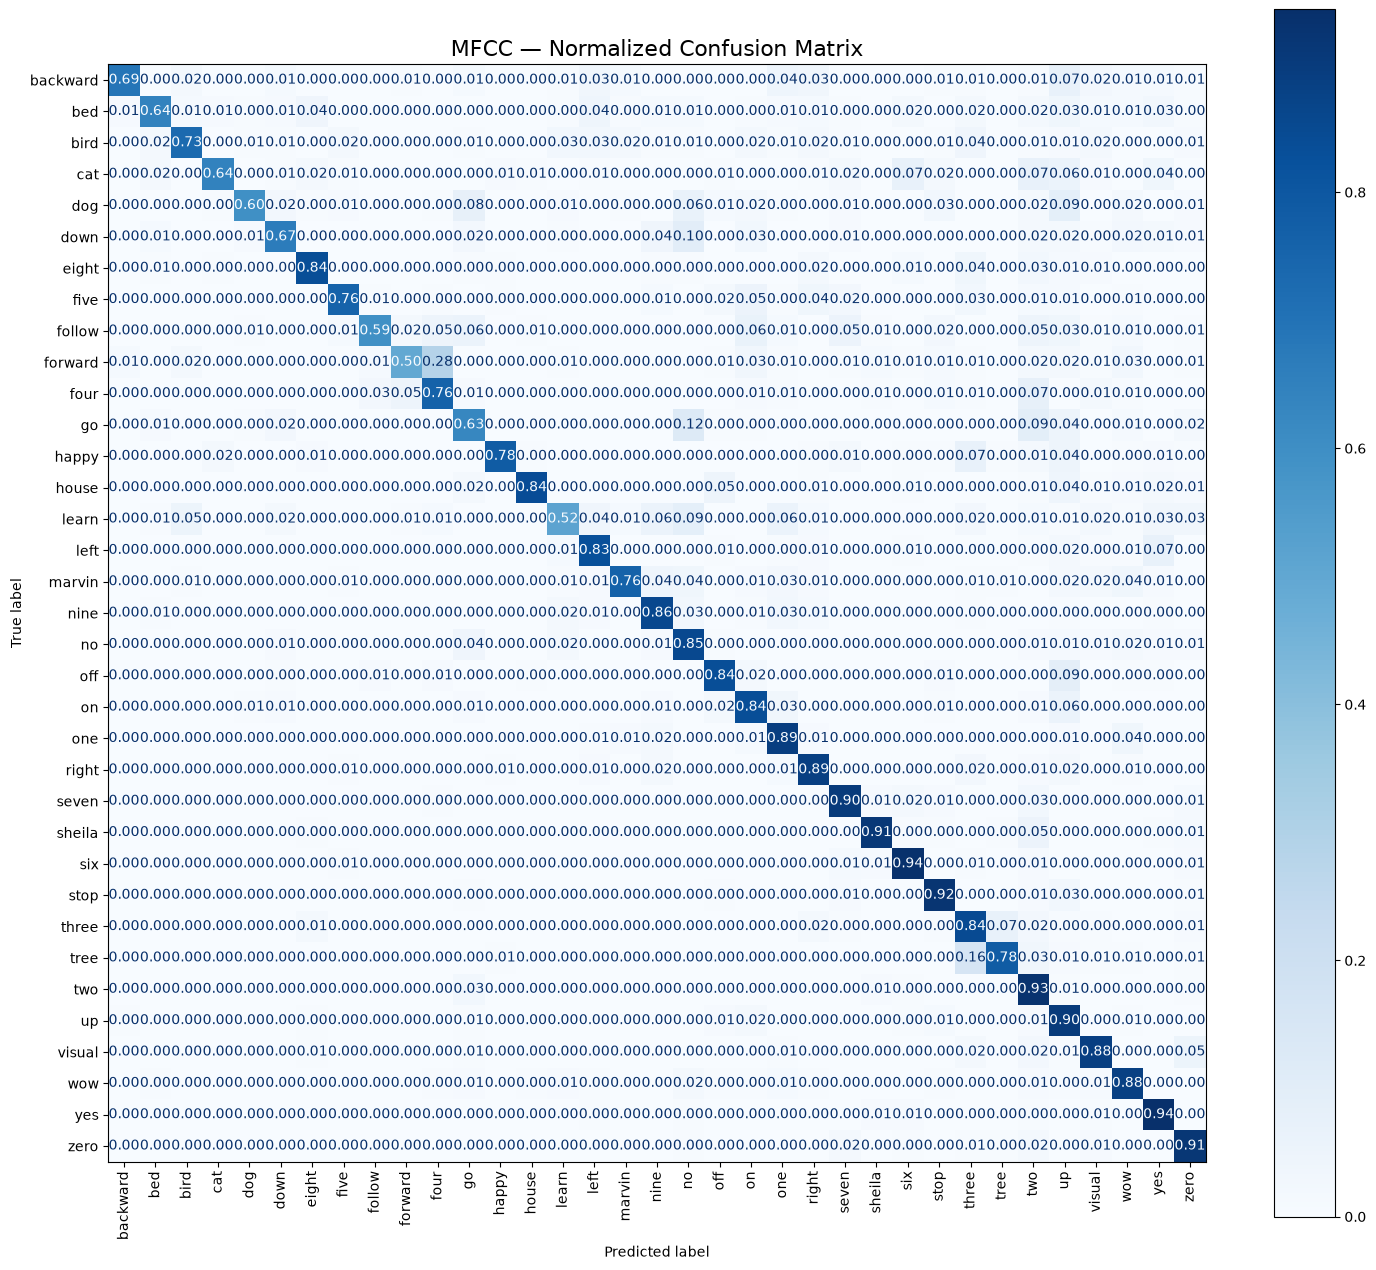

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

for feature_name in models_by_feature:

    prediction_file = (
        EVAL_DIR / f"{feature_name.lower()}_predictions.npz"
    )

    data = np.load(prediction_file)

    y_true = data["y_true"]
    y_pred = data["y_pred"]

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=np.arange(num_classes),
        normalize="true",
    )

    fig, ax = plt.subplots(figsize=(15, 13))

    display_cm = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels,
    )

    display_cm.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=90,
        values_format=".2f",
        colorbar=True,
    )

    ax.set_title(
        f"{feature_name} — Normalized Confusion Matrix",
        fontsize=16,
    )

    plt.tight_layout()

    plt.savefig(
        EVAL_DIR / f"{feature_name.lower()}_confusion_matrix.png",
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()